# Optimisation Quantique des Paramètres pour CHSH mod 4

## Objectif
Ce fichier implémente une stratégie d’optimisation **indépendante pour chaque configuration** d’entrée $(x, y) \in \{0,1,2,3\}^2$ dans le jeu CHSH mod 4. L’objectif est de :

- Générer un circuit quantique personnalisé pour chaque paire $(x, y)$
- Utiliser un ansatz paramétré par 8 angles pour **Alice** et 8 pour **Bob**
- Maximiser le taux de succès quantique :
  
  $$
  \text{Succès} \iff (a + b) \bmod 4 = (x \cdot y) \bmod 4
  $$

- Utiliser l’algorithme d’optimisation **COBYLA** pour chaque paire $(x, y)$
- Stocker les meilleurs paramètres dans un dictionnaire pour une utilisation ultérieure

Le fichier inclut aussi une visualisation de la **matrice des succès optimisés** sur toutes les combinaisons $(x, y)$.

## Génération de l'État de Bell à 4 Qubits

Cette fonction initialise un état intriqué entre Alice (qubits 0 et 1) et Bob (qubits 2 et 3) en deux étapes :

1. **Superposition quantique** sur les qubits d’Alice avec des portes Hadamard ($H$)
2. **Intrication** avec les qubits de Bob via des portes de type CNOT

Le résultat est une version **quartit** de l’état de Bell, où chaque joueur contrôle deux qubits formant un système à 4 niveaux.


In [16]:
from itertools import product

# Sorties possibles (quartits)
outputs = [0, 1, 2, 3]

# Entrées possibles pour Alice et Bob (maintenant 0, 1, 2, 3)
inputs = [0, 1, 2, 3]

# Génère toutes les fonctions f_A : {0,1,2,3} → {0,1,2,3}
strategies_A = list(product(outputs, repeat=4))  # f_A(x) = a
strategies_B = list(product(outputs, repeat=4))  # f_B(y) = b


print(f"Nombre total de stratégies classiques : {len(strategies_A)} (Alice) x {len(strategies_B)} (Bob)")

max_success_rate = 0
best_strategies = []

# Teste toutes les combinaisons de stratégies classiques
for strategy_A in strategies_A:
    for strategy_B in strategies_B:
        success = 0
        total = 0
        for x in inputs:
            for y in inputs:
                a = strategy_A[x]  # Alice répond à x
                b = strategy_B[y]  # Bob répond à y
                win = (a + b) % 4 == (x * y) % 4
                success += int(win)
                total += 1
        success_rate = success / total
        if success_rate > max_success_rate:
            max_success_rate = success_rate
            best_strategies = [(strategy_A, strategy_B)]
        elif success_rate == max_success_rate:
            best_strategies.append((strategy_A, strategy_B))

# Affiche les résultats
print(f"\nMeilleure probabilité de succès (classique, 4x4 inputs) : {max_success_rate*100:.2f}%")
print("Exemples de stratégies optimales :")
for i, (sA, sB) in enumerate(best_strategies[:5]):
    print(f"{i+1}. Alice : {sA}, Bob : {sB}")

Nombre total de stratégies classiques : 256 (Alice) x 256 (Bob)

Meilleure probabilité de succès (classique, 4x4 inputs) : 62.50%
Exemples de stratégies optimales :
1. Alice : (0, 0, 0, 2), Bob : (0, 1, 0, 3)
2. Alice : (0, 0, 2, 0), Bob : (0, 0, 2, 0)
3. Alice : (0, 1, 0, 3), Bob : (0, 0, 0, 2)
4. Alice : (0, 1, 2, 1), Bob : (3, 0, 1, 0)
5. Alice : (0, 2, 0, 0), Bob : (0, 3, 0, 1)


In [2]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit.circuit.library import RYGate, CZGate, CXGate, SwapGate
from qiskit.circuit import Parameter
import numpy as np

def bell_quartit_state():
    qc = QuantumCircuit(4)
    # Étape 1 : superposition des deux premiers qubits
    qc.h(0)
    qc.h(1)

    # Étape 2 : intrication avec les deux derniers
    qc.cx(0, 2)
    qc.cx(1, 3)
    return qc

# Definition de l'ansatz

- Un ansatz à $4$ couches composé de rotations $RY$ suivies de portes $CX$.  

- Chaque ansatz prend $8$ paramètres  $\theta_0, \theta_1, \dots, \theta_7$.

In [23]:
from qiskit.circuit import QuantumCircuit, ParameterVector
global params_per_player
params_per_player = 8
def quartit_ansatz(prefix):

    """
    Construct a parametrized quantum ansatz for a 2-qubit system.

    This ansatz applies 4 alternating layers of single-qubit RY rotations 
    followed by a CX (CNOT) entangling gate. Each layer contains two RY rotations 
    (one per qubit). The final layer includes only RY rotations.

    The ansatz is defined by 8 parameters (θ₀ to θ₇), applied in the following order:

        - Layer 1: RY(θ₀) on qubit 0, RY(θ₁) on qubit 1, CX(0→1)
        - Layer 2: RY(θ₂), RY(θ₃), CX(0→1)
        - Layer 3: RY(θ₄), RY(θ₅), CX(0→1)
        - Layer 4: RY(θ₆), RY(θ₇)

    Parameters
    ----------
    prefix : str
        A string used as a prefix for naming the parameters (e.g., "a0", "b2").

    Returns
    -------
    qc : qiskit.QuantumCircuit
        A 2-qubit quantum circuit representing the ansatz.

    θ : qiskit.circuit.ParameterVector
        A vector of 8 symbolic parameters used in the ansatz.
    """
    θ = ParameterVector(prefix, 8)
    qc = QuantumCircuit(2)

    qc.ry(θ[0], 0)
    qc.ry(θ[1], 1)
    qc.cx(0, 1)

    qc.ry(θ[2], 0)
    qc.ry(θ[3], 1)
    qc.cx(0, 1)

    qc.ry(θ[4], 0)
    qc.ry(θ[5], 1)
    qc.cx(0, 1)

    qc.ry(θ[6], 0)
    qc.ry(θ[7], 1)

  
    

    return qc, θ


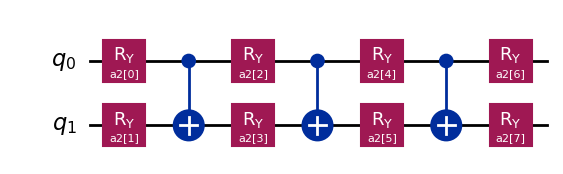

In [4]:
# Pour x = 2
ansatz, theta_params = quartit_ansatz("a2")
ansatz.draw('mpl')

# exemple du circuit dans un cas donné

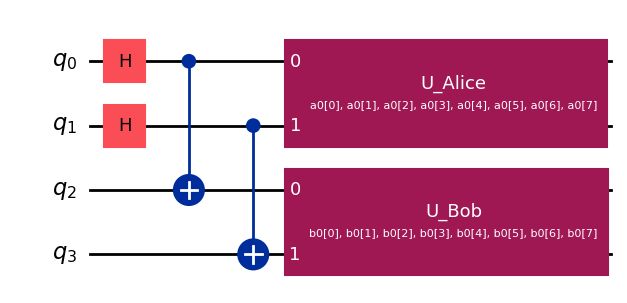

In [24]:
# Création du circuit global
qc = bell_quartit_state()

# Génération de l'ansatz (par ex. pour x = 0)
ansatz, θ = quartit_ansatz("a0")

# Ajout de l'ansatz d'Alice sur les qubits 0 et 1
qc.append(ansatz.to_gate(label="U_Alice"), [0, 1])

ansatz, θ = quartit_ansatz("b0")
# Ajout de l'ansatz de Bob sur les qubits 2 et 3
qc.append(ansatz.to_gate(label="U_Bob"), [2, 3])
# Affichage du circuit
qc.draw('mpl')

# Généralisation et Optimisation 

# Construction du circuit quantique

## Description
Cette fonction construit un circuit à 4 qubits pour modéliser le jeu CHSH avec quartits. Elle applique d'abord un état de Bell sur les 4 qubits, puis les ansätze paramétrés pour Alice et Bob selon les entrées $x$ et $y$.

## Paramètres
- `theta_A_values` : angles de rotation pour Alice
- `theta_B_values` : angles de rotation pour Bob
- `x`, `y` : entrées du jeu pour Alice et Bob, telles que $x, y \in \{0, 1, 2, 3\}$
- `params_per_player` : nombre de paramètres par joueur (ici 8) cela correspond à la configuration de l'ansatz

## Retour
- `qc` : circuit quantique complet pour les entrées $(x, y)$


In [41]:
def build_circuit(theta_A_values, theta_B_values, x, y, params_per_player):
    qc = bell_quartit_state()

    # Ansatz Alice
    theta_A = theta_A_values[params_per_player * x : params_per_player * (x + 1)]
    ansatz_A, param_A = quartit_ansatz(f"a{x}")
    param_dict_A = {p: v for p, v in zip(param_A, theta_A)}
    qc.append(ansatz_A.assign_parameters(param_dict_A).to_gate(), [0, 1])

    # Ansatz Bob
    theta_B = theta_B_values[params_per_player * y : params_per_player * (y + 1)]
    ansatz_B, param_B = quartit_ansatz(f"b{y}")
    param_dict_B = {p: v for p, v in zip(param_B, theta_B)}
    qc.append(ansatz_B.assign_parameters(param_dict_B).to_gate(), [2, 3])


    return qc

# Évaluation du taux de succès 

# Description
Cette cellule calcule le **taux de succès** d’un jeu quantique basé sur un ansatz à rotations Ry.  
Pour chaque combinaison d’entrées (x, y) des joueurs Alice et Bob, le circuit quantique est construit, exécuté en simulation, et les probabilités des états finaux sont analysées pour déterminer si la condition de succès est respectée.

# Paramètres
- `theta` : tableau des angles de rotation pour tous les joueurs  
  - `theta_A_values` : angles de rotation pour Alice (extraits de `theta`)  
  - `theta_B_values` : angles de rotation pour Bob (extraits de `theta`)  
- `params_per_player` : nombre de paramètres par joueur et par couche Ry (ici 8)  

# Sortie
- `success / total` : taux de succès moyen, compris entre 0 et 1

In [42]:
%matplotlib inline
# ----------------------
# Calcul du taux de succès
# ----------------------
# Nombre de paramètres par joueur et par entrée ( ici 4 pour les 4 couches de rotation Ry sur l'ansatz )



def compute_success(theta):
    theta_A_values = theta[:params_per_player * 4] 
    theta_B_values = theta[params_per_player * 4:]

    success = 0
    total = 0
    for x in range(4):
            for y in range(4):
                qc = build_circuit(theta_A_values, theta_B_values, x, y, params_per_player)
                qc.draw('mpl')
                state = Statevector.from_instruction(qc)
                probs = np.abs(state.data) ** 2
                for idx, p in enumerate(probs):
                    if p > 1e-6:
                        bin_str = format(idx, '04b')  # q0 q1 q2 q3
                        a = int(bin_str[0]) * 2 + int(bin_str[1])  # Alice : q0 q1
                        b = int(bin_str[2]) * 2 + int(bin_str[3])  # Bob   : q2 q3
                        # print(f"a = {a}, b = {b}, p = {p:.2f}")
                        # print(f"x = {x}, y = {y}")
                        if (a + b) % 4 == (x * y) % 4:
                            success += p
                total += 1
    
    return success / total

# Optimisation des paramètres

# Description
Cette cellule effectue l’optimisation des angles de rotation (`theta`) pour maximiser le taux de succès du jeu quantique.  
Elle utilise l’algorithme **COBYLA** de `scipy.optimize.minimize` avec une initialisation des paramètres à π/2.  
L’évolution du taux de succès est suivie et affichée tous les 50 itérations.

# Paramètres
- `params_per_player` : nombre de paramètres par joueur (utilisé pour déterminer la taille de `theta`)  
- `initial_theta` : tableau initial des angles de rotation (π/2 par défaut)  
- `compute_success(theta)` : fonction qui retourne le taux de succès pour un tableau de paramètres donné  

# Sortie
- `result` : objet `OptimizeResult` retourné par `scipy.optimize.minimize`  
- `optimal_theta` : tableau des angles de rotation optimisés correspondant au taux de succès maximal  
- Affiche un graphique montrant l’évolution du taux de succès au cours des itérations
## Règle optimisée
$$
\text{Maximiser} \quad \mathbb{P}[(a + b) \bmod 4 = (x \cdot y) \bmod 4]
$$

In [43]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
print(params_per_player*4*2)
def optimize_chsh4():
    np.random.seed(42)
    initial_theta = np.full(params_per_player *4*2, np.pi/2)  # Initialisation des paramètres à π/2
    print(f"Initial theta : {initial_theta}")

    iteration = {'count': 0}
    history = {'iterations': [], 'success_rate': []}  # Pour stocker l'historique

    def cost(theta):
        return -compute_success(theta)

    def callback(theta):
        iteration['count'] += 1
        if iteration['count'] % 50 == 0:
            current_success = compute_success(theta)
            history['iterations'].append(iteration['count'])
            history['success_rate'].append(current_success)
            print(f"[Étape {iteration['count']}] Taux de succès : {current_success * 100:.2f}%")
            print(f"Thêta courant : {theta}\n")

    result = minimize(
        cost,
        initial_theta,
        method='COBYLA',
        callback=callback,
        options={'maxiter': 2000}
    )

    optimal_theta = result.x
    optimal_success = -result.fun

    print(f"✅ Taux de succès quantique optimal : {optimal_success * 100:.2f}%")
    print(f"🎯 Thêta finaux optimisés : {optimal_theta}")

    # === Affichage du graphique final ===
    plt.figure(figsize=(10, 5))
    plt.plot(history['iterations'], np.array(history['success_rate']) * 100, marker='o')
    plt.title("Evolution of Success Rate During Optimization")
    plt.xlabel("Iterations")
    plt.ylabel("Success Rate (%)")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    return result, optimal_theta

64


Initial theta : [1.57079633 1.57079633 1.57079633 1.57079633 1.57079633 1.57079633
 1.57079633 1.57079633 1.57079633 1.57079633 1.57079633 1.57079633
 1.57079633 1.57079633 1.57079633 1.57079633 1.57079633 1.57079633
 1.57079633 1.57079633 1.57079633 1.57079633 1.57079633 1.57079633
 1.57079633 1.57079633 1.57079633 1.57079633 1.57079633 1.57079633
 1.57079633 1.57079633 1.57079633 1.57079633 1.57079633 1.57079633
 1.57079633 1.57079633 1.57079633 1.57079633 1.57079633 1.57079633
 1.57079633 1.57079633 1.57079633 1.57079633 1.57079633 1.57079633
 1.57079633 1.57079633 1.57079633 1.57079633 1.57079633 1.57079633
 1.57079633 1.57079633 1.57079633 1.57079633 1.57079633 1.57079633
 1.57079633 1.57079633 1.57079633 1.57079633]
[Étape 50] Taux de succès : 41.77%
Thêta courant : [2.57079633 1.57079633 1.57079633 1.57079633 1.57079633 1.57079633
 1.57079633 2.57079633 2.57079633 1.57079633 1.57079633 1.57079633
 1.57079633 1.57079633 1.57079633 1.57079633 2.57079633 1.57079633
 1.57079633 1.57

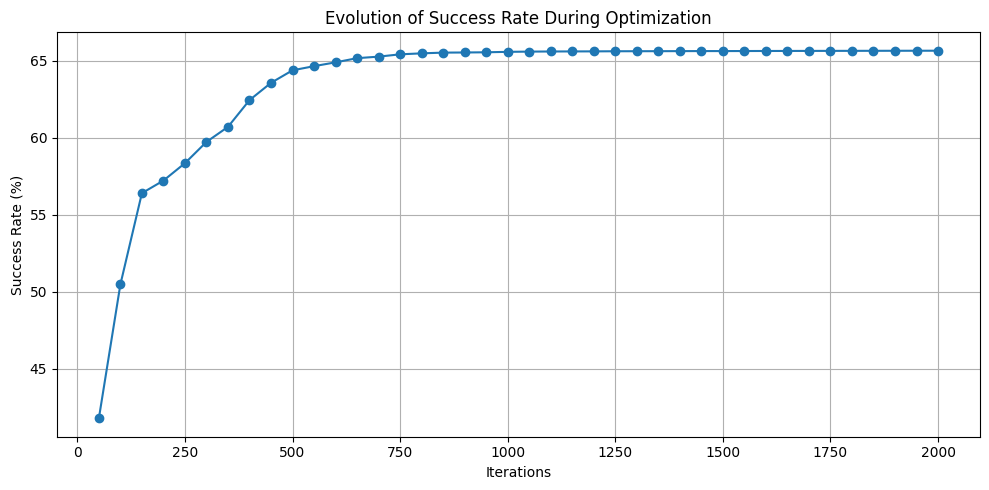

In [44]:
result, optimal_theta = optimize_chsh4()

# optimisation supplémentaire avec des paramètres pré-définis et pré-optimisés

In [ ]:
from scipy.optimize import minimize

def optimize_chsh4_for_a_given_set():
    np.random.seed(42)
    initial_theta = np.array([
    -0.78828768,  2.83192151,  1.45766093,  0.61988954, -2.16129862, -2.16145018,
    -2.77664256,  2.30075258,  0.63532436,  1.30735856, -3.01225646,  2.95253068,
     2.08879872, -1.80742667, -1.99915269, -1.98922813, -1.22998226,  0.15554925,
    -0.42760206, -1.311746,    0.70279246, -2.26512688, -1.30599369, -0.8396733,
    -0.27602043,  1.79181341, -1.88700528,  0.08943761,  0.58065786, -2.8497361,
     0.67572423, -2.07015799, -2.73286144,  2.82043101,  2.92565235,  1.93771769,
    -1.22764789, -2.52790066,  1.15757025, -0.37603297, -2.37480381, -0.03030437,
    -2.9255232,   2.57183594, -1.51563008,  1.02115763, -1.1830542,   0.1260911,
     0.29348934, -1.98011785,  2.95048723,  1.72871051,  2.76145329,  2.48077341,
     0.61512371,  2.65071399, -2.58557786, -1.91019601, -2.85742122, -1.0974819,
    -0.69946122, -1.4366564,   2.06551869, -0.90004539, -1.37642907,  0.2682674,
    -2.25613963,  1.89875963, -2.67317714,  3.05920085,  1.71056433, -1.8930252,
    -3.10689617,  1.98210261,  1.29972302,  1.43889447,  1.70444186, -2.67635639,
    -0.88928605, -2.41356588,  2.28144611,  0.77470498, -1.06249905, -2.74224376,
    -1.1876331,  -1.09840558,  1.44265817,  0.86429908,  2.43292941, -0.17457877,
    -2.39015984,  1.33985651,  1.63856079,  0.38501599,  1.702537,   -0.03898342
])

    print(f"Initial theta : {initial_theta}")

    # Stocke l’état de l’optimisation à chaque appel
    iteration = {'count': 0}

    def cost(theta):
        return -compute_success(theta)

    def callback(theta):
        iteration['count'] += 1
        if iteration['count'] % 100 == 0:
            current_success = compute_success(theta)
            print(f"[Étape {iteration['count']}] Taux de succès : {current_success * 100:.2f}%")
            print(f"Thêta courant : {theta}\n")

    options_2 = {'disp': False, 'maxiter': 150, 'gtol': 1e-5}
    print(f"Initial theta : {initial_theta}")
    result = minimize(
            cost,
            initial_theta,
            method='BFGS',
            callback=callback,
            options=options_2
        )
    optimal_theta = result.x
    optimal_success = -result.fun

    print(f"✅ Taux de succès quantique optimal : {optimal_success * 100:.2f}%")
    print(f"🎯 Thêta finaux optimisés : {optimal_theta}")

    return result, optimal_theta

(x=0, y=0) ➤ Taux de succès optimal : 100.00%
Paramètres optimaux pour Alice : [1.57079633 1.57079633 1.57079633 1.57079633 1.57079633 1.57079633
 1.57079633 1.57079633]
Paramètres optimaux pour Bob : [1.57079633 1.57079633 1.57079633 1.57079633 1.57079633 1.57079633
 1.57079633 1.57079633]
(x=0, y=1) ➤ Taux de succès optimal : 100.00%
Paramètres optimaux pour Alice : [1.57079633 1.57079633 1.57079633 1.57079633 1.57079633 1.57079633
 1.57079633 1.57079633]
Paramètres optimaux pour Bob : [1.57079633 1.57079633 1.57079633 1.57079633 1.57079633 1.57079633
 1.57079633 1.57079633]
(x=0, y=2) ➤ Taux de succès optimal : 100.00%
Paramètres optimaux pour Alice : [1.57079633 1.57079633 1.57079633 1.57079633 1.57079633 1.57079633
 1.57079633 1.57079633]
Paramètres optimaux pour Bob : [1.57079633 1.57079633 1.57079633 1.57079633 1.57079633 1.57079633
 1.57079633 1.57079633]
(x=0, y=3) ➤ Taux de succès optimal : 100.00%
Paramètres optimaux pour Alice : [1.57079633 1.57079633 1.57079633 1.57079633 

KeyboardInterrupt: 